Copyright (c) 2025 Data Charmers Pty Ltd. All rights reserved. Please do not distribute.

# Network analysis with NetworkX

[NetworkX (http://networkx.github.io/)](http://networkx.github.io/) is a Python library for working with complex graphs (or networks). In graph theory a graph or network is made up of nodes connected by edges. Nodes and edges may have attributes associated with them, and these attributes can be used to define costs to travel between nodes, latencies for packet-routing between nodes, etc.

NetworkX supports two basic kinds of graphs:

1. A standard *undirected* graph with self-loops. This only supports up to a single edge between a given pair of nodes.
2. A standard *directed* graph with self-loops. This only supports a single edge of each direction between a given pair of nodes.

NetworkX also support multigraphs, both undirected and directed. Multigraphs support multiple edges between pairs of nodes.

**Note** NetworkX does not support graphs which are both undirected and directed. Instead represent these as a directed graph with an edge travelling in both directions for the edges which are undirected.

In [1]:
%matplotlib inline

In [2]:
import matplotlib.pyplot as plt
import random

import networkx as nx

NetworkX graphs share the same base class, so they have all the same attributes and methods available irrespective of how they were created.

In [3]:
g = nx.Graph()       # undirected
dg = nx.DiGraph()    # directed

NetworkX graph objects have identical methods for adding nodes and edges.

In [4]:
g.add_node("A")
dg.add_node("A")
g.add_nodes_from(["B", "C", "D"])
dg.add_nodes_from(["B", "C", "D"])

Nodes are identified by the key added. This key can be any hashable object.

Adding a node a second time will overwrite the attributes of the original node.

In [5]:
g.add_node("A", cost=1)
g.nodes(data=True)

[('B', {}), ('C', {}), ('A', {'cost': 1}), ('D', {})]

Similarly, adding edges to graphs is done through the same methods regardless of the graph type. Edges are added in the form `(from_node, to_node)`. For an undirected graph this doesn't matter, but in a directed graph unless you add an edge connecting the "to node" back to the "from node", the "to node" has no way to reach the "from node".

In [6]:
g.add_edge("A", "B", weight=1)
g.add_edges_from([["A", "C"], ["A", "D"],], weight=1)
dg.add_edge("A", "B", weight=1)
dg.add_edges_from([["A", "C"], ["A", "D"],], weight=1)

NetworkX has a number of in-built drawing methods for visualising graphs. You can supply a dictionary of positions for each node as well with the `pos` argument;

In [ ]:
{"A": (0,0), "B": (1,1), "C": (0, 1), "D": (1, 0)}

This makes it easy to relate the graph back to real world positions:

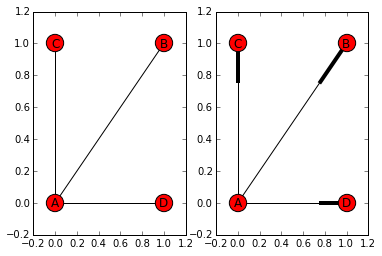

In [7]:
pos = {"A": (0,0), "B": (1,1), "C": (0, 1), "D": (1, 0)}

plt.subplot(121)
nx.draw_networkx(g, pos=pos)
plt.subplot(122)
nx.draw_networkx(dg, pos=pos)

## NetworkX Algorithms

NetworkX contains a large number of algorithms available for exploratory data analysis. One example is using the graph to determine the maximum throughput of a network. Consider a graph as a representation of water pipelines, each of which has a maximum capacity.

First we can use the one of the in-built methods to build a random directed graph:

In [8]:
g = nx.grid_2d_graph(5, 4, create_using=nx.DiGraph())
g = nx.convert_node_labels_to_integers(g) #Relabel from coordinates to integers to make the graph easy to work with

Then we want to randomly assign maximum flow to the edges of the network. In this case we'll call the attribute `capacity`.

In [9]:
capacity = {edge: random.randint(0, 10) + 1 for edge in g.edges_iter()}
nx.set_edge_attributes(g, "capacity", capacity)
g[0]

{9: {'capacity': 3}, 3: {'capacity': 3}, 7: {'capacity': 3}}

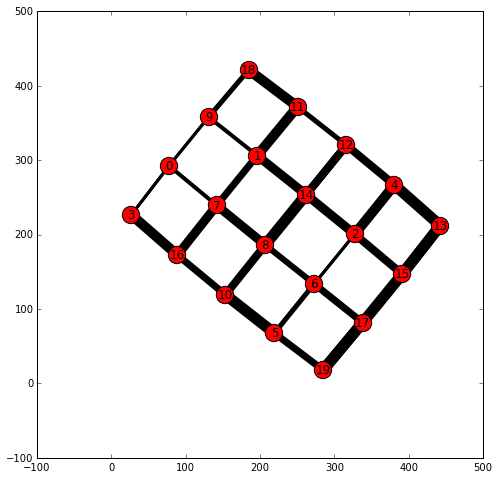

In [10]:
plt.figure(figsize=(8, 8))
pos = nx.graphviz_layout(g)
nx.draw_networkx_edges(g, pos=pos, width=[edge[2]["capacity"] for edge in g.edges_iter(data=True)], arrows=False)
nx.draw_networkx_nodes(g, pos=pos)
_ = nx.draw_networkx_labels(g, pos=pos)

Now we want to find the maximum single commodity flow between a pair of nodes. In this case we'll assume that we're interested in nodes `0` and `19`. This requires the name of an edge attribute for determining the capacity, which in our case is `capacity`.

The `maximum_flow` method returns two parameters - a maximum flow value, and a dictionary containing the flows between nodes.

In [11]:
max_flow, edge_flow = nx.maximum_flow(g, 0, 19, capacity="capacity")
max_flow

9

We can use the dictionary of edge flow to visualise the flow through the network.

In [12]:
edges = {(a, b): val for a, receivers in edge_flow.items() for b, val in receivers.items() if val > 0}

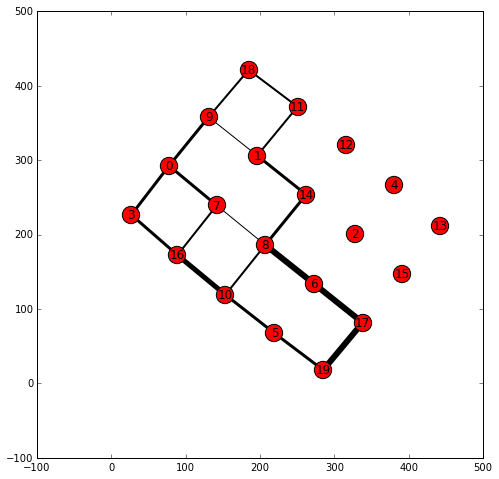

In [13]:
plt.figure(figsize=(8, 8))
nx.draw_networkx_edges(g, pos=pos, edgelist=edges, width=list(edges.values()), arrows=False)
nx.draw_networkx_nodes(g, pos=pos)
_ = nx.draw_networkx_labels(g, pos=pos)

Now consider that you have a number of inflow and a number of outflow points. This can be modelled as a demand attribute on nodes. Positive demand is a node wanting to receive flow, a negative demand is a node wanting to send flow. Network demand must sum to zero or the cost flow for the graph will be infeasible.

In this case we will model demand as a negative 5 on the zero node, a negative 5 on the 1 node, and a positive 10 on the 19 node. If the demand attribute is not present on a node it will be assumed to be zero.

In [14]:
g.node[0]["demand"] = -5
g.node[1]["demand"] = -5
g.node[19]["demand"] = 10

The `network_simplex` method is one method of calculating demand cost flow. It uses the leaving arc rule to prevent cycling. It returns a cost (which is calculated on an optional weight attribute on edges) and a dictionary mapping edges to the capacity throughput.

In [15]:
cost, edge_flow = nx.network_simplex(g, demand="demand", capacity="capacity")

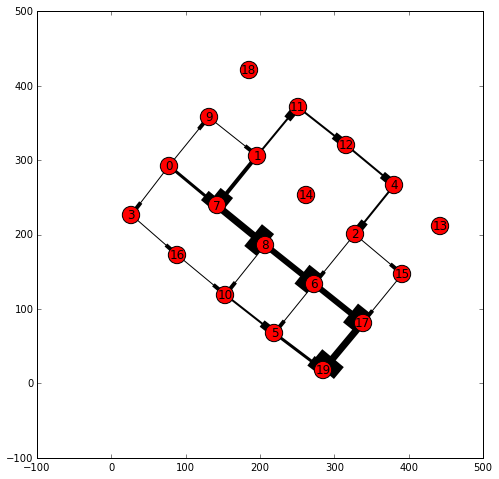

In [16]:
edges = {(a, b): val for a, receivers in edge_flow.items() for b, val in receivers.items() if val > 0}
plt.figure(figsize=(8, 8))
nx.draw_networkx_edges(g, pos=pos, edgelist=edges, width=list(edges.values()), arrows=True)
nx.draw_networkx_nodes(g, pos=pos)
_ = nx.draw_networkx_labels(g, pos=pos)